# **About Porter**

Porter is India's largest intra-city logistics marketplace and a leader in the country's $40 billion intra-city logistics market. It connects restaurants, customers, and delivery partners to provide fast and reliable on-demand delivery services. Porter has served over 5 million customers and supports more than 150,000 delivery partners across multiple cities.

# **Problem Statement**

Porter works with numerous restaurants and delivery partners to deliver food to customers. The company wants to accurately estimate the delivery time for each order based on order details, restaurant location, customer location, and delivery partner information. Accurate delivery time predictions help improve customer experience, enhance customer satisfaction, and optimize logistics operations.


# **Objective**

Build an Artificial Neural Network (ANN) regression model to accurately predict food delivery time using order, restaurant, customer, and delivery-related features. The model aims to:

*  Provide accurate delivery time estimates to improve customer satisfaction.
Reduce customer complaints caused by inaccurate estimated delivery times (ETAs).

*  Support efficient delivery partner allocation and route planning.
Improve overall logistics efficiency.

* Enable data-driven decision-making for operational improvements.

#**Importing Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Loading Dataset**

In [ ]:
df = pd.read_csv("data_2.csv")
df

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175772,1.0,2015-02-17 00:19:41,2015-02-17 01:02:41,28,4.0,3,1389,3,345,649,17.0,17.0,23.0,331.0
175773,1.0,2015-02-13 00:01:59,2015-02-13 01:03:59,28,4.0,6,3010,4,405,825,12.0,11.0,14.0,915.0
175774,1.0,2015-01-24 04:46:08,2015-01-24 05:32:08,28,4.0,5,1836,3,300,399,39.0,41.0,40.0,795.0
175775,1.0,2015-02-01 18:18:15,2015-02-01 19:03:15,58,1.0,1,1175,1,535,535,7.0,7.0,12.0,384.0


#**Basic Exploration of Data**

In [ ]:
#Shape of data
df.shape

(175777, 14)

In [ ]:
#Columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

The dataset consists of **17,577 observations and 14 features**. Out of these, **2 features are date type (object type)**, and the remaining are numerical features comprising continuous variables and discrete count-based attributes.

In [ ]:
df.nunique()

,0
market_id,6
created_at,162649
actual_delivery_time,160344
store_primary_category,73
order_protocol,7
total_items,54
subtotal,8182
num_distinct_items,20
min_item_price,2251
max_item_price,2585


In [ ]:
#Missing values
df.isnull().sum()

,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


There are no missing values in the dataset, indicating that the data is complete and does not require imputation.

In [ ]:
#Check for duplicate records
df.duplicated().sum()

np.int64(0)

There are no duplicate records in the dataset.

**Statistical summary**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
market_id,175777.0,2.743726,1.330963,1.0,2.0,2.0,4.0,6.0
store_primary_category,175777.0,35.887949,20.728254,0.0,18.0,38.0,55.0,72.0
order_protocol,175777.0,2.911752,1.513128,1.0,1.0,3.0,4.0,7.0
total_items,175777.0,3.204976,2.674055,1.0,2.0,3.0,4.0,411.0
subtotal,175777.0,2697.111147,1828.554893,0.0,1412.0,2224.0,3410.0,26800.0
num_distinct_items,175777.0,2.675060,1.625681,1.0,1.0,2.0,3.0,20.0
min_item_price,175777.0,684.965433,519.882924,-86.0,299.0,595.0,942.0,14700.0
max_item_price,175777.0,1160.158616,560.828571,0.0,799.0,1095.0,1395.0,14700.0
total_onshift_dashers,175777.0,44.918664,34.544724,-4.0,17.0,37.0,66.0,171.0
total_busy_dashers,175777.0,41.861381,32.168505,-5.0,15.0,35.0,63.0,154.0


**Insights**

*  Some features contain negative values, which are not possible in real life. This may be due to errors in the data. and should be checked before further analysis.

*  **total_items:** Most customers place small orders with around 2 - 4 items. A few very large orders exist (max - 411), and these may take longer to prepare, which can lead to slower deliveries.

*  **num_distinct_items:** Most customers order only 1 - 3 different item types. A few orders contain up to 20 unique items, which may take longer to prepare and deliver.

*  On average, about **45 delivery drivers** are on duty, and around **42** of them are already busy. This leaves only a few drivers available, which may cause delivery delays when many new orders arrive at the same time.

*  **total_outstanding_ordersOn average:** Around 58 orders are pending at any given time. A high number of pending orders can increase the workload on restaurants and delivery drivers, potentially leading to longer delivery times.

*  **estimated_store_to_consumer_driving_duration:** The average estimated driving time from the store to the customer is about 9 minutes. However, some deliveries may require up to 35 minutes of travel, which could contribute to longer delivery times.

**Date type conversion**

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     175777 non-null  float64       
 1   created_at                                    175777 non-null  datetime64[ns]
 2   actual_delivery_time                          175777 non-null  datetime64[ns]
 3   store_primary_category                        175777 non-null  int64         
 4   order_protocol                                175777 non-null  float64       
 5   total_items                                   175777 non-null  int64         
 6   subtotal                                      175777 non-null  int64         
 7   num_distinct_items                            175777 non-null  int64         
 8   min_item_price                                175777 n

**Feature engineering**

In [ ]:
df['created_at']-df['actual_delivery_time']
df['hour']=df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek

In [ ]:
df['delivery_duration_min'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()/60


# **Exploratory Data Analysis (EDA)**

## **Univariate Analysis**

## Distributions of Numerical Features

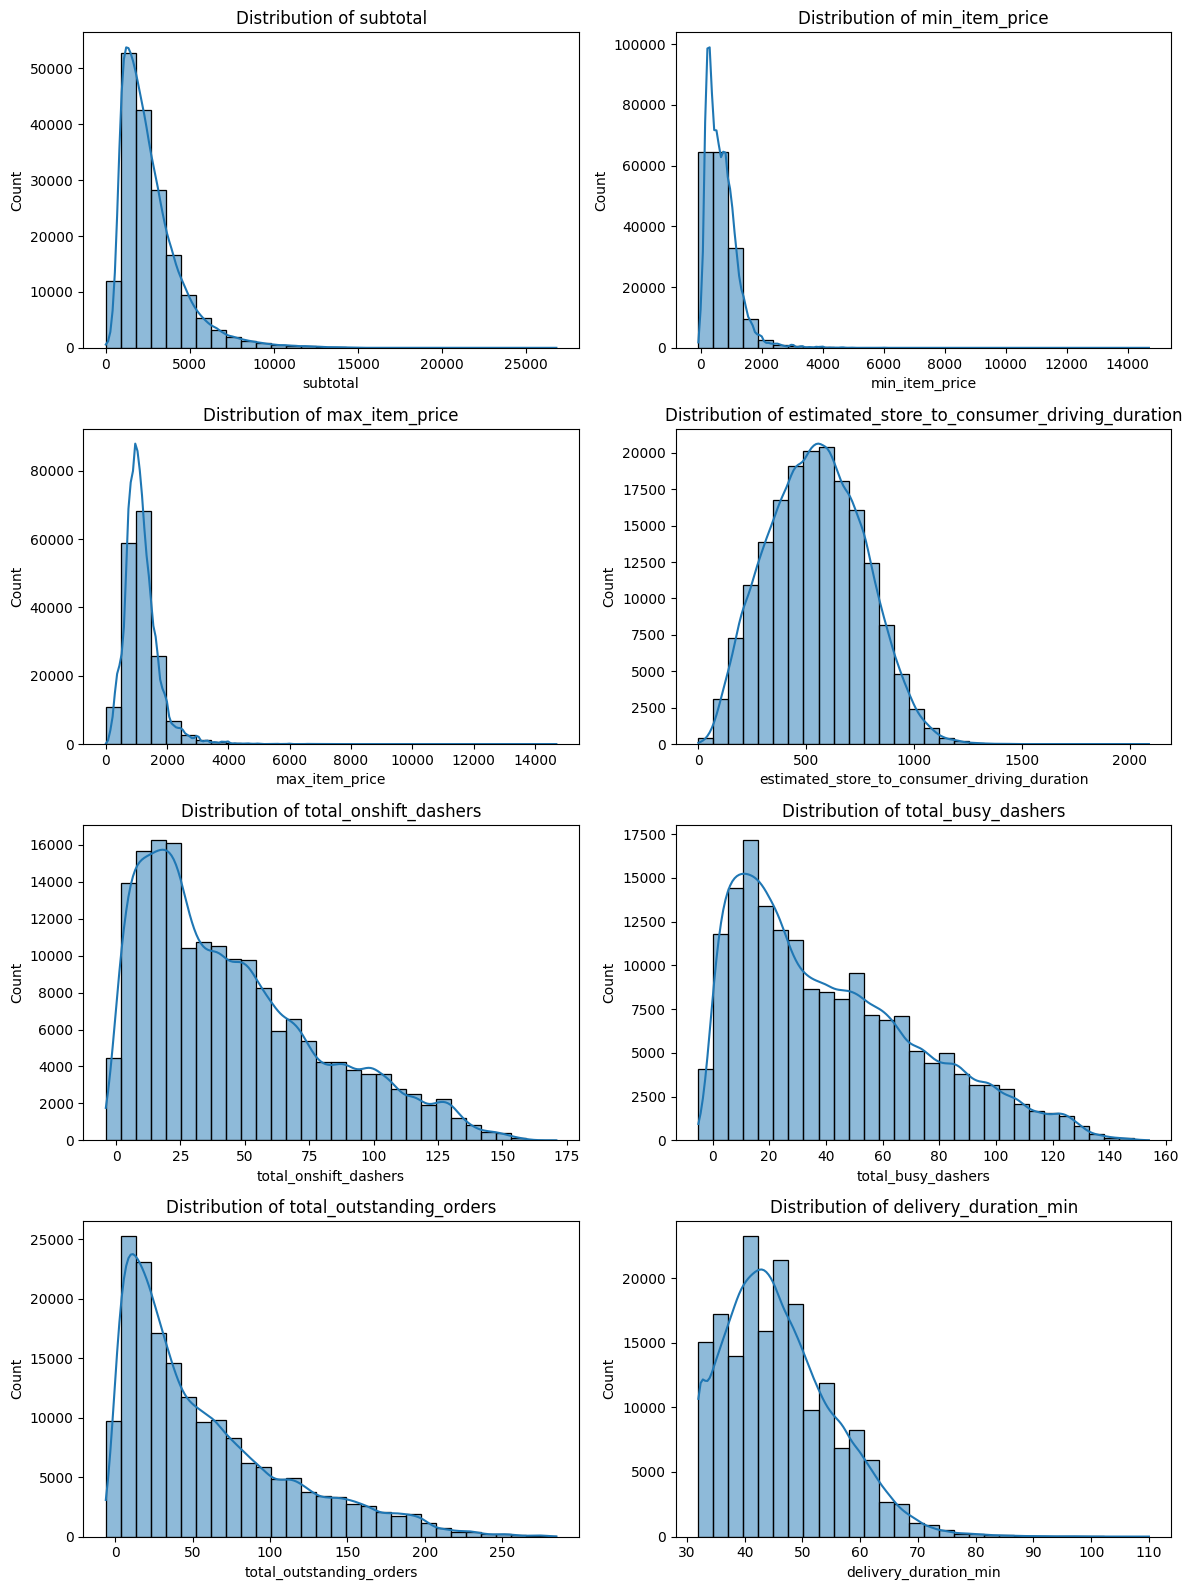

In [ ]:
hist_col = [
    "subtotal", "min_item_price", "max_item_price", "estimated_store_to_consumer_driving_duration",
             "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders", "delivery_duration_min"
             ]

plt.figure(figsize=(12, 16))

for i, col in enumerate(hist_col, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**Insight**

*  **Right-Skewed Distributions:**  Features such as **subtotal, item prices, total outstanding orders, and the number of active dashers** exhibit a right-skewed distribution. This indicates that Most orders on the Portex platform are standard-sized, reflecting regular demand patterns. However, occasional surges in order value and demand suggest peak periods that may require increased staffing and operational capacity to ensure timely deliveries.

*  **Approximately Normal Distributions:** Variables related to driving duration and delivery duration appear to follow a more symmetric, bell-shaped distribution. This indicates that most customers receive their orders within an expected timeframe. This indicates relatively stable delivery operations, although a small number of deliveries may be affected by factors such as traffic congestion, weather conditions, or route-specific challenges.

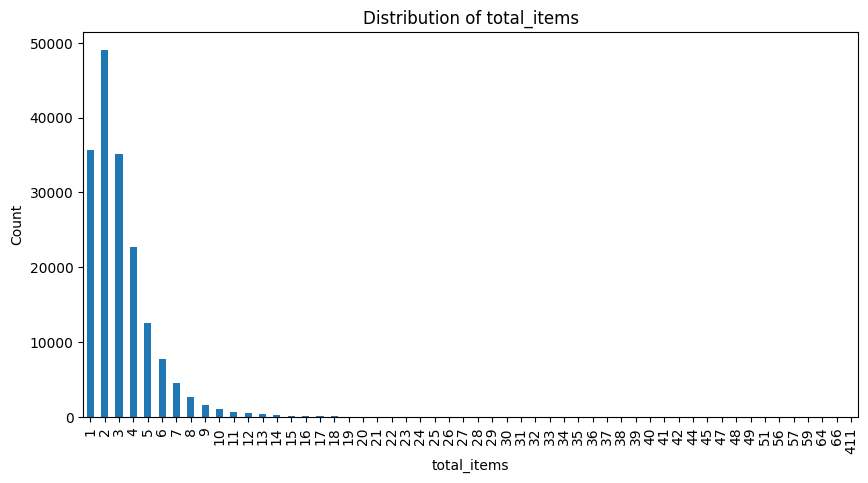

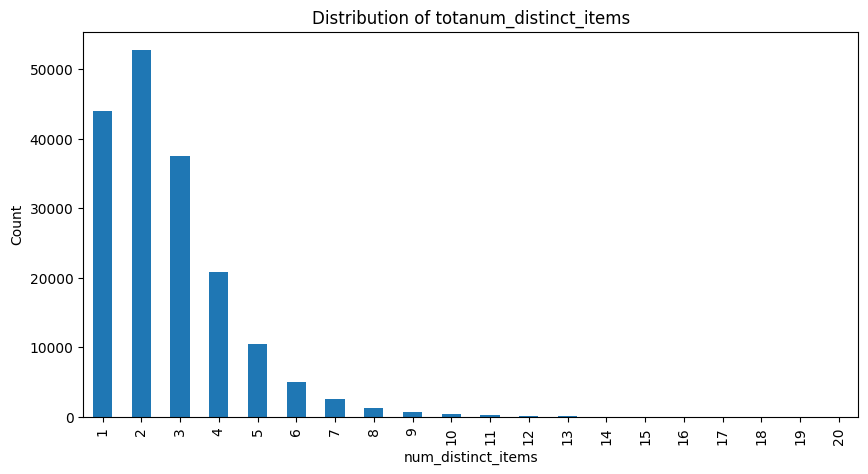

In [ ]:
plt.figure(figsize=(10, 5))

df['total_items'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of total_items')
plt.xlabel('total_items')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

plt.figure(figsize=(10, 5))

df['num_distinct_items'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of totanum_distinct_items')
plt.xlabel('num_distinct_items')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

**Insight**

*  Both **total items** and **distinct items** per order are concentrated around **1-3 items**, indicating that customers typically place small orders with only a few unique items.

*  Large multi-item orders are relatively rare, suggesting that the platform primarily caters to individual customers or small groups rather than bulk purchases.

## Distributions of Categorical Features

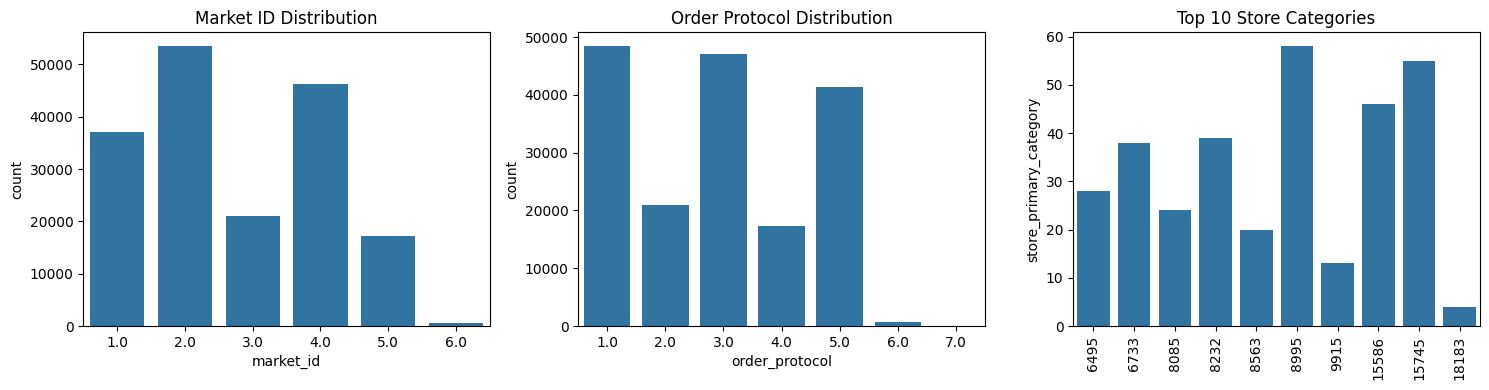

In [ ]:
plt.figure(figsize=(15, 4))

# 1. Market ID
plt.subplot(1, 3, 1)
sns.countplot(x='market_id', data=df)
plt.title('Market ID Distribution')

# 2. Order Protocol
plt.subplot(1, 3, 2)
sns.countplot(x='order_protocol', data=df)
plt.title('Order Protocol Distribution')

# 3. Store Primary Category (Top 10)
plt.subplot(1, 3, 3)

top_categories = df['store_primary_category'].value_counts().nlargest(10)
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.xticks(rotation = 90)

plt.title('Top 10 Store Categories')

plt.tight_layout()
plt.show()

**Insight**

*  **Market ID 2.0** and **4.0** dominate the dataset, with Market 2.0 contributing the highest volume of orders, while **Market 6.0** has minimal representation.

*  **Order protocols** are also **unevenly distributed**, with a few protocols handling most transactions and others being rarely used.

* **store primary categories** show a highly skewed distribution, where a small number of categories account for the majority of orders, while many categories contribute very little.


# **Outlier Detection**

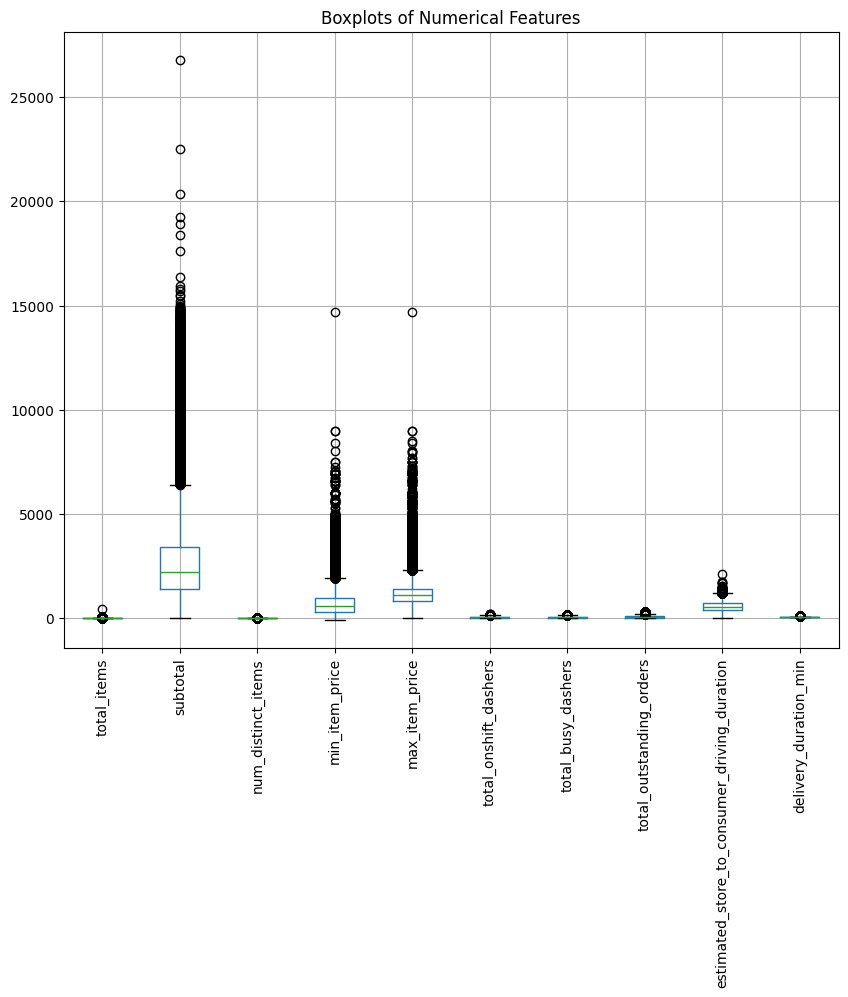

In [ ]:
outlier = [
    'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration', 'delivery_duration_min',
]

plt.figure(figsize=(10,8))
df[outlier].boxplot(rot=90)
plt.title('Boxplots of Numerical Features')
plt.show()

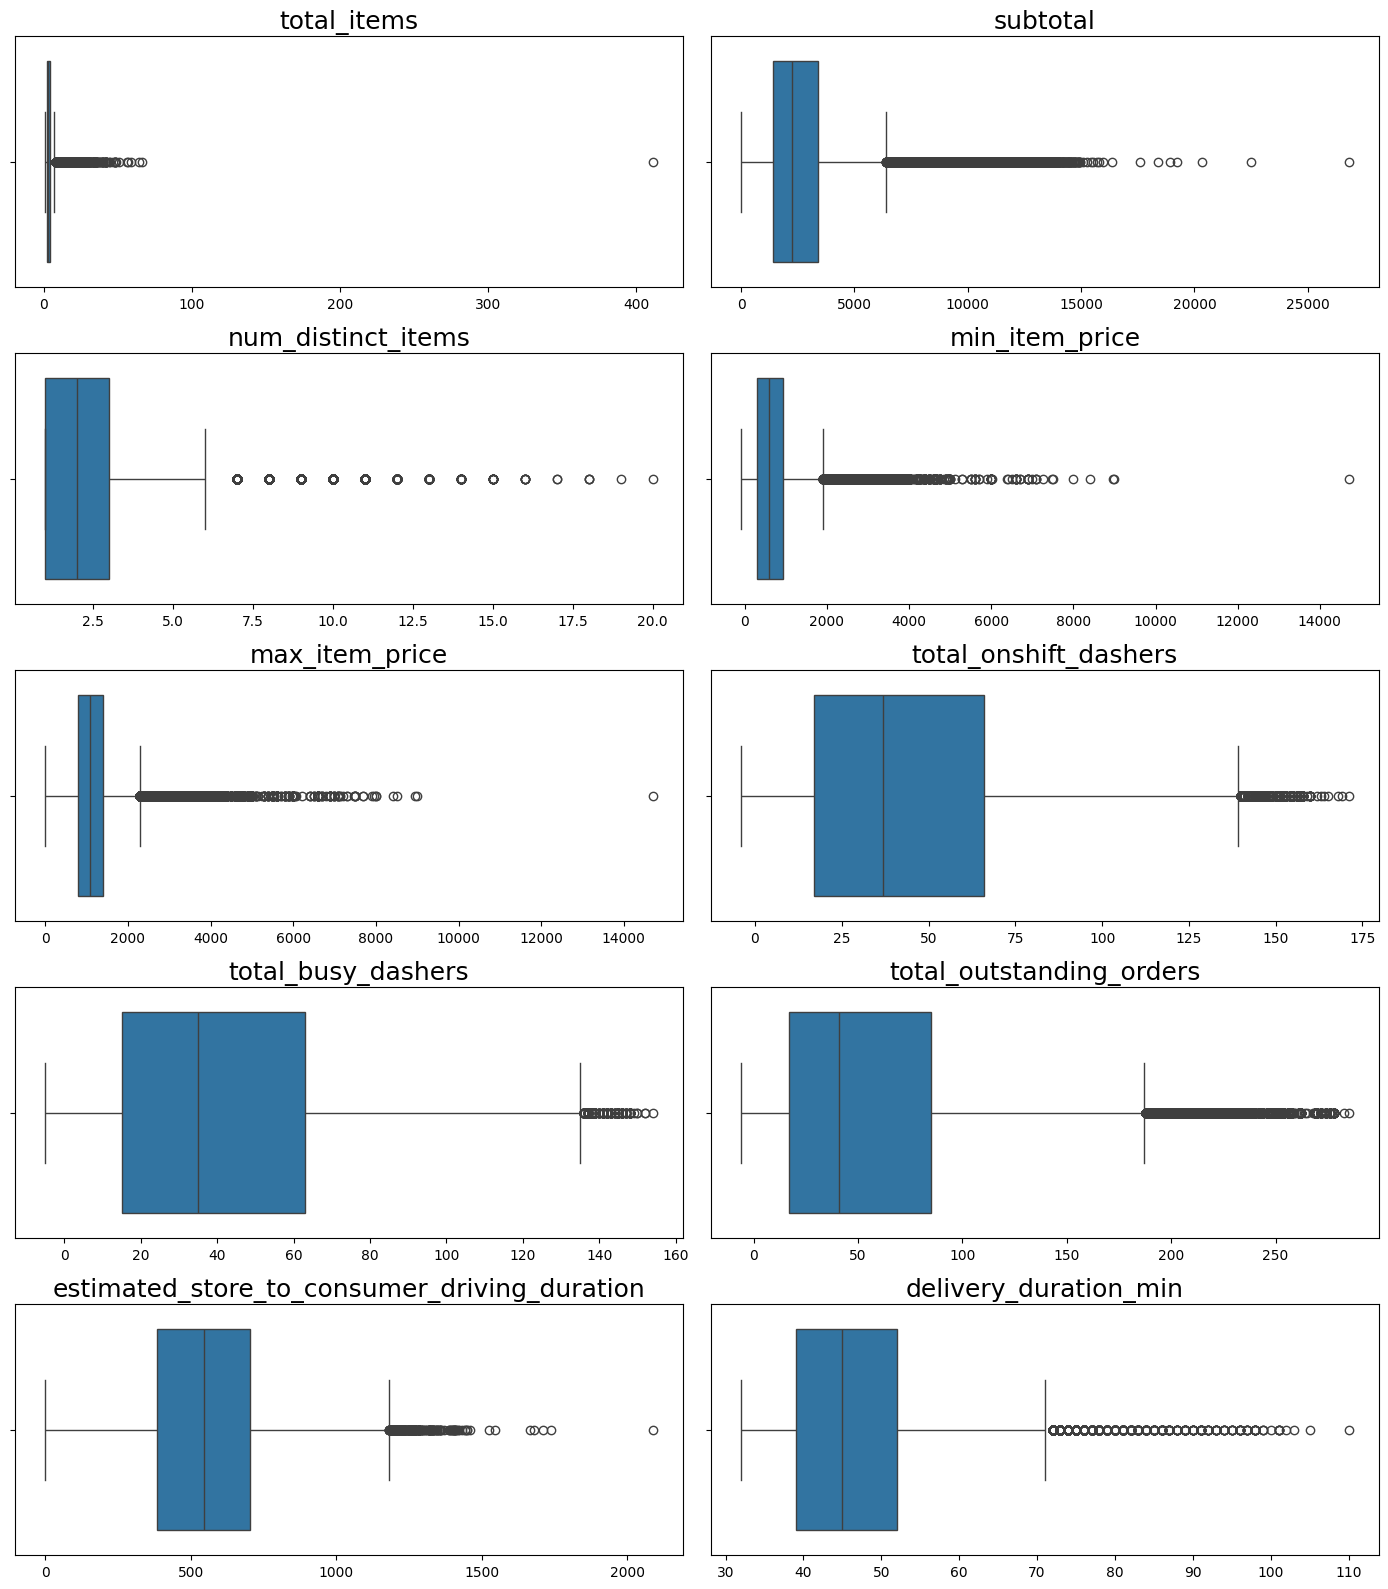

In [ ]:

plt.figure(figsize=(14, 16))  # Generous height so plots don't look squished

for i, col in enumerate(outlier, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"{col}", fontsize=18)
    plt.xlabel("")  # Clean up the axis label

plt.tight_layout()
plt.show()

**Insight**

*  The boxplots reveal strong skewness and outliers in pricing features **(subtotal, min_item_price, max_item_price)** and **occasional extreme** values in **total_items**.

*  **Operational features** are relatively stable, while the **target variable(delivery_duration_min)** shows several high-value outliers, with delivery delays extending up to 110 minutes.

*  Since the outliers represent genuine real-world delivery scenarios rather than data errors, they were retained to preserve the natural variability in the dataset.


# **Bivariate Analysis**

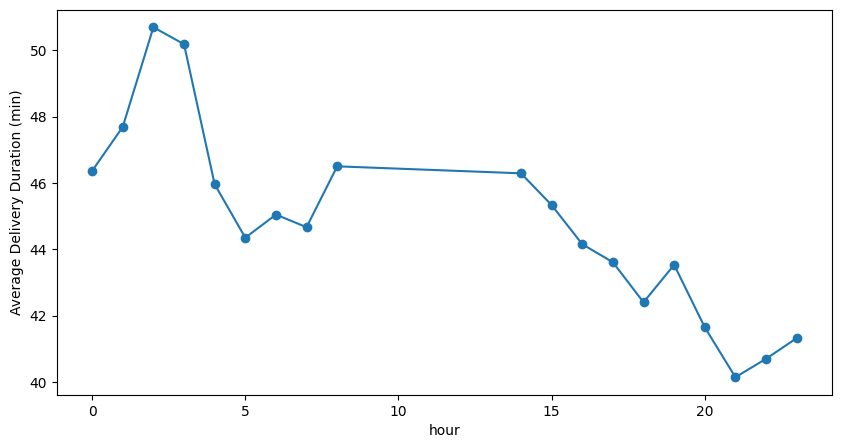

In [ ]:
plt.figure(figsize=(10,5))
df.groupby('hour')['delivery_duration_min'].mean().plot(
    kind='line', marker='o'
)
plt.ylabel('Average Delivery Duration (min)')
plt.show()

**Insight**

*  Delivery duration shows a generally **downward trend** throughout the day. The **highest average delivery times** are observed during the early morning hours **(around 2-3 AM)** and the lowest is around , after which delivery times gradually decrease as the day progresses.

*  The **lowest delivery durations** are observed around **9 PM (hour 21)**, indicating more efficient deliveries during that period.

*  The sharp peak in delivery time during the early morning hours is unlikely to be caused by traffic congestion. Instead, it may be attributed to lower driver availability, limited restaurant operations, the presence of outliers, or a small number of deliveries during those hours, which can inflate the average delivery time.

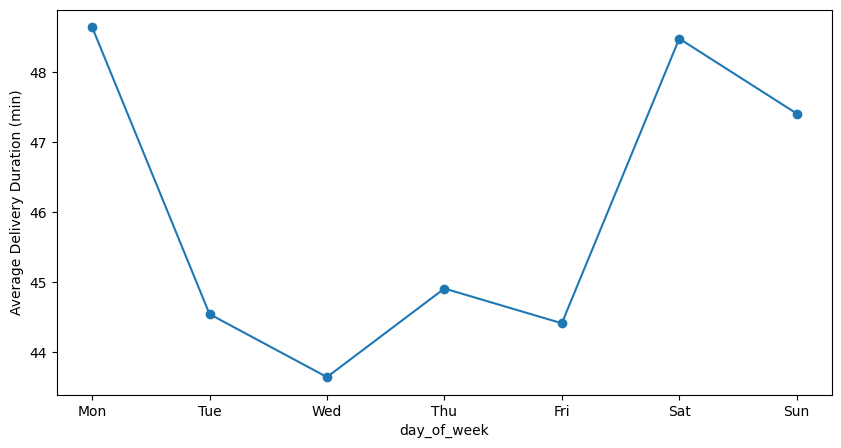

In [ ]:
plt.figure(figsize=(10,5))
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df.groupby('day_of_week')['delivery_duration_min'].mean().plot(
    kind='line',marker='o'
)
plt.ylabel('Average Delivery Duration (min)')
plt.xticks(
    ticks=range(7),
    labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
)
plt.show()

**Insight**

*  **Average delivery duration** is **highest on Monday** and **Saturday** (around 48 - 49 minutes) and lowest on Wednesday (around 41 -42 minutes).

*   The higher delivery time on Saturday may be due to increased order volume. The reason for the Monday peak is unclear and would require further analysis of factors such as order demand and driver availability.

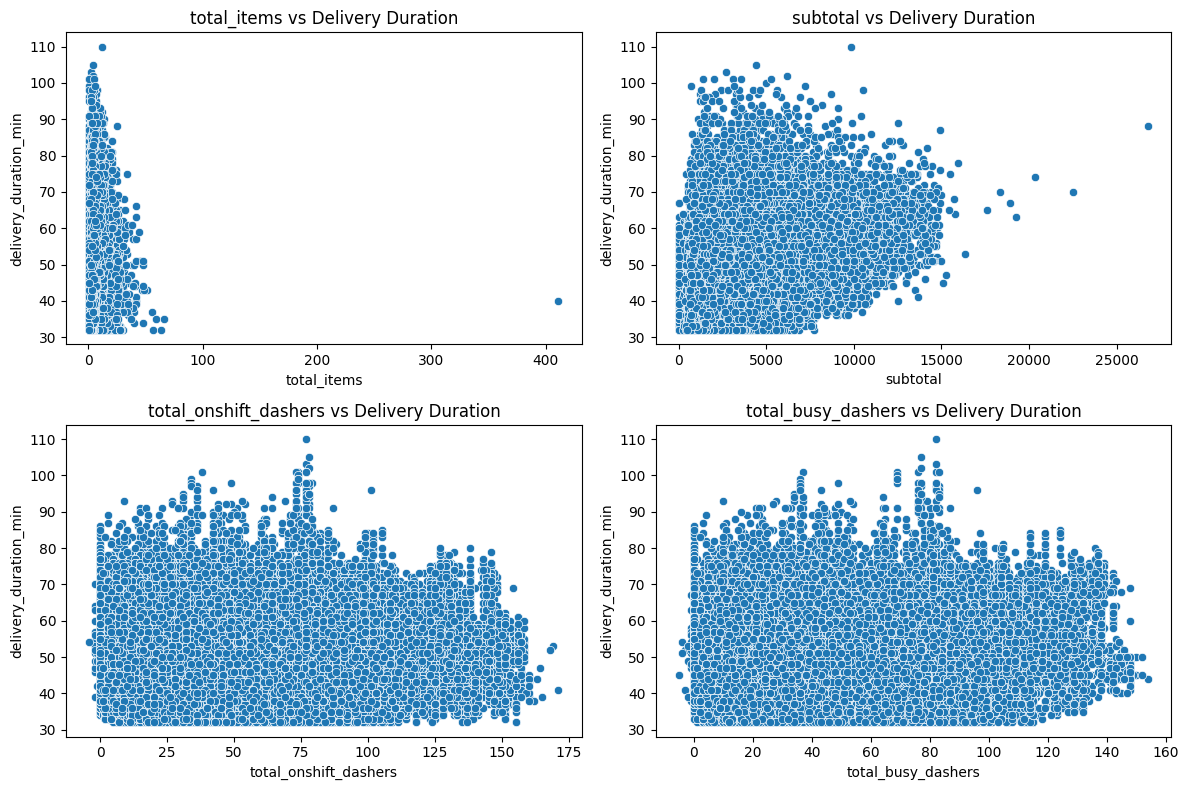

In [ ]:
sca_col = ['total_items', 'subtotal', 'total_onshift_dashers','total_busy_dashers']

plt.figure(figsize=(12,8))

for i, col in enumerate(sca_col, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=col, y='delivery_duration_min', data=df)
    plt.title(f"{col} vs Delivery Duration")

plt.tight_layout()
plt.show()

**Insight**

*  The scatter plots show no clear relationship between **total items, subtotal**, and **delivery duration**, indicating that order size and value are not major drivers of delivery time. Even high-item or high-value orders do not consistently lead to longer deliveries.

*  In contrast, **higher on-shift dasher availability** is associated with fewer extreme delays, suggesting that operational factors such as driver availability play a more significant role in delivery performance than order characteristics.


## Correlation Analysis

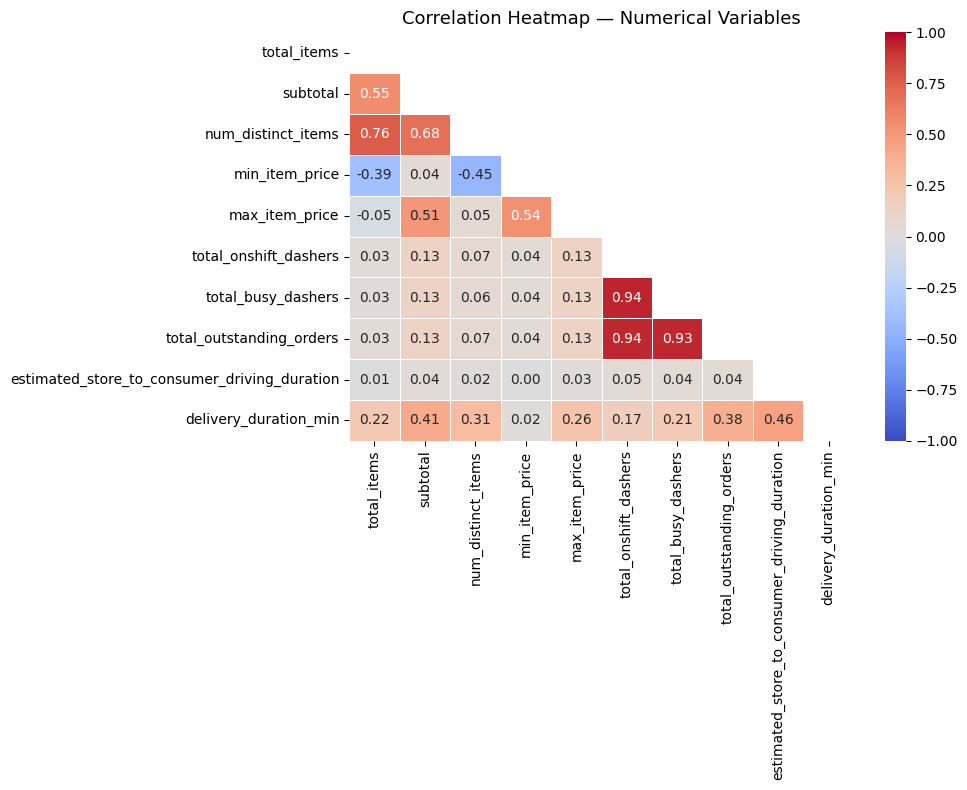

In [ ]:
num_cols = [
    'total_items',
    'subtotal',
    'num_distinct_items',
    'min_item_price',
    'max_item_price',
    'total_onshift_dashers',
    'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration',
    'delivery_duration_min'
    ]

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            mask=mask,
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap — Numerical Variables', fontsize=13)
plt.tight_layout()
plt.show()

**Insight**

*  **Estimated store-to-consumer driving duration** shows the strongest relationship with **delivery time (correlation = 0.46).** This suggests that travel distance and driving time are among the most important factors influencing overall delivery duration.

*  **Total busy dashers** and **total on-shift dashers** are highly correlated (94%).

*  No single feature has a very strong correlation with delivery time.
This indicates that delivery performance is influenced by multiple factors rather than any single variable. The scatter plots also show no clear linear relationship between the input features and the target, suggesting non-linear relationships that are better captured by models such as ANNs and tree-based ensembles.



## Feature and Target Separation

In [ ]:
X = df.drop(
    ['created_at', 'actual_delivery_time', 'delivery_duration_min'], axis=1
    )
y = df['delivery_duration_min']

## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# First split — Train (80%) and Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Second split — Validation (10%) and Test (10%) from Temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Train size:      ", X_train.shape)
print("Validation size: ", X_val.shape)
print("Test size:       ", X_test.shape)

Train size:       (140621, 14)
Validation size:  (17578, 14)
Test size:        (17578, 14)


## Encoding Categorical Variables

In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_cols = ['market_id', 'order_protocol']

# 1. Fit on Train
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.fit(X_train[cat_cols])

# 2. Transform train
train_encoded = ohe.transform(X_train[cat_cols])
train_encoded_df = pd.DataFrame(train_encoded,
                                columns=ohe.get_feature_names_out(cat_cols),
                                index=X_train.index)


# 3. Transform Val
val_encoded = ohe.transform(X_val[cat_cols])
val_encoded_df = pd.DataFrame(val_encoded,
                              columns=ohe.get_feature_names_out(cat_cols),
                              index=X_val.index)

# 4. Transform  test
test_encoded = ohe.transform(X_test[cat_cols])
test_encoded_df = pd.DataFrame(test_encoded,
                               columns=ohe.get_feature_names_out(cat_cols),
                               index=X_test.index)


# 4. Drop original columns and concat
X_train = pd.concat([X_train.drop(cat_cols, axis=1), train_encoded_df], axis=1)
X_val = pd.concat([X_val.drop(cat_cols, axis=1), val_encoded_df], axis=1)
X_test  = pd.concat([X_test.drop(cat_cols, axis=1), test_encoded_df], axis=1)


In [ ]:
#Target Encoding
category_means = pd.concat(
    [X_train['store_primary_category'], y_train],
    axis=1
).groupby('store_primary_category')['delivery_duration_min'].mean()

X_train['store_category_encoded'] = X_train['store_primary_category'].map(category_means)
X_val['store_category_encoded'] = X_val['store_primary_category'].map(category_means)
X_test['store_category_encoded'] = X_test['store_primary_category'].map(category_means)

In [ ]:
X_train.drop('store_primary_category', axis=1, inplace=True)
X_val.drop('store_primary_category', axis=1, inplace=True)
X_test.drop('store_primary_category', axis=1, inplace=True)

In [ ]:
print(X_train['store_category_encoded'].isna().sum())
print(X_val['store_category_encoded'].isna().sum())
print(X_test['store_category_encoded'].isna().sum())

0
1
0


In [ ]:
global_mean = y_train.mean()

X_train['store_category_encoded'] = X_train['store_category_encoded'].fillna(global_mean)
X_val['store_category_encoded'] = X_val['store_category_encoded'].fillna(global_mean)
X_test['store_category_encoded'] = X_test['store_category_encoded'].fillna(global_mean)


In [ ]:
X_train.select_dtypes(exclude='number').columns

Index([], dtype='object')

## Scaling the data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = [
    'total_items', 'subtotal', 'num_distinct_items',
    'min_item_price', 'max_item_price',
    'total_onshift_dashers', 'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration',
    'hour', 'day_of_week',
    'store_category_encoded'
]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

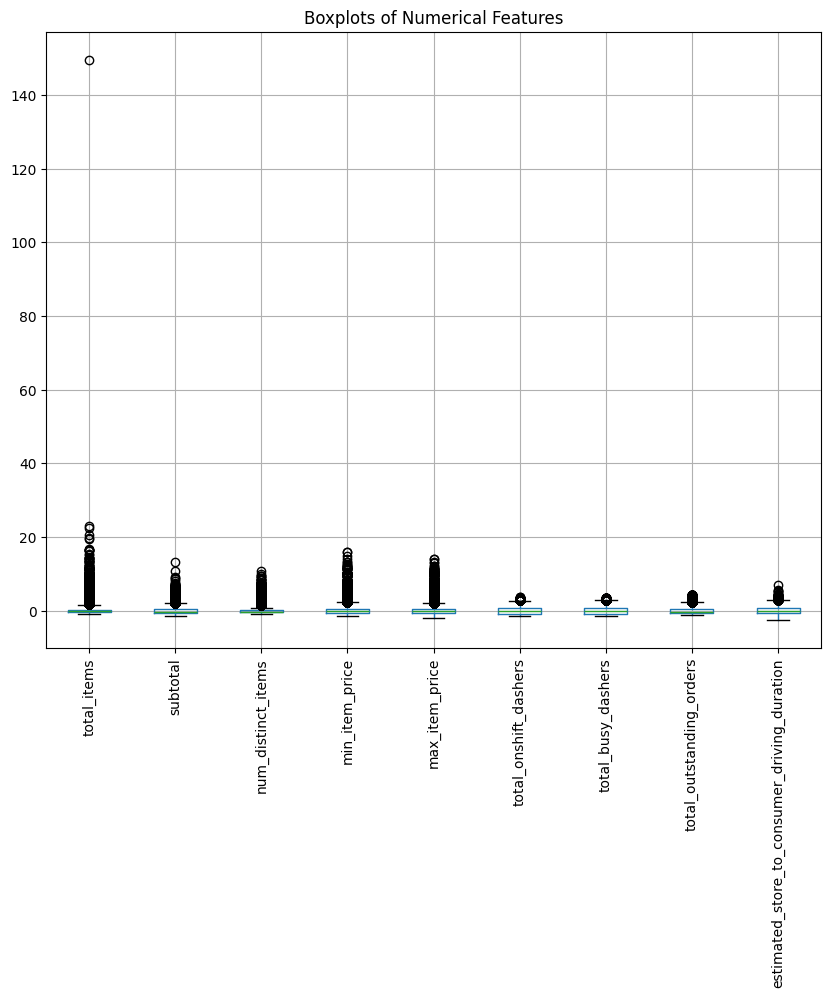

In [ ]:
out = ['total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration',
]

plt.figure(figsize=(10,8))
X_train[out].boxplot(rot=90)
plt.title('Boxplots of Numerical Features')
plt.show()

After scaling, the features became easier to compare on the same scale. Some outliers remain, but they were retained as they likely represent genuine business cases.


## Building the BaselineArtificial Neural Network (ANN)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],), name='hidden_1'),
    Dense(32, activation='relu', name='hidden_2'),
    Dense(16, activation='relu', name='hidden_3'),
    Dense(1,  name='output')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 47.8591 - mae: 2.9801 - val_loss: 1.5622 - val_mae: 0.9470
Epoch 2/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.9080 - mae: 0.7026 - val_loss: 0.5437 - val_mae: 0.5656
Epoch 3/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.4653 - mae: 0.5152 - val_loss: 0.3267 - val_mae: 0.4421
Epoch 4/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.3119 - mae: 0.4342 - val_loss: 0.2672 - val_mae: 0.4054
Epoch 5/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2817 - mae: 0.4095 - val_loss: 0.2321 - val_mae: 0.3826
Epoch 6/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.2577 - mae: 0.3960 - val_loss: 0.2406 - val_mae: 0.3869
Epoch 7/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2503 - mae: 0.3889 - val_loss: 0.2140 - val_mae: 0.3653
Epoch 8/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2449 - mae: 0.3800 - val_loss: 0.2187 - val_mae: 0.3705
Epoch 9/100
4395/4395 ━━━

## Plotting Learning Curves

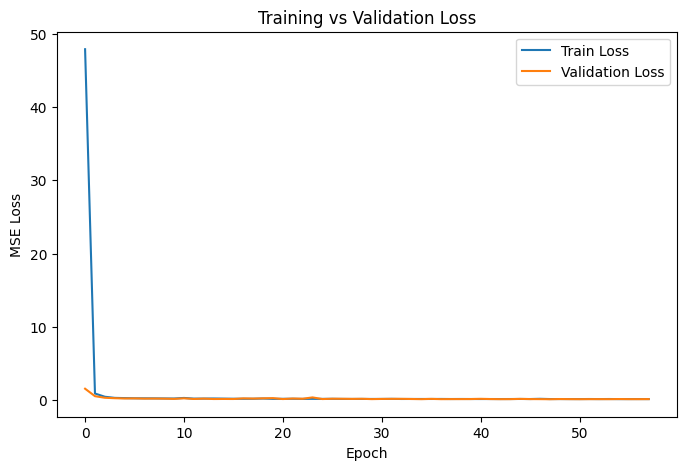

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

The model converged within the first few epochs, after which both training and validation loss stabilized at very low values. The close alignment between the two curves suggests good generalization with minimal overfitting.

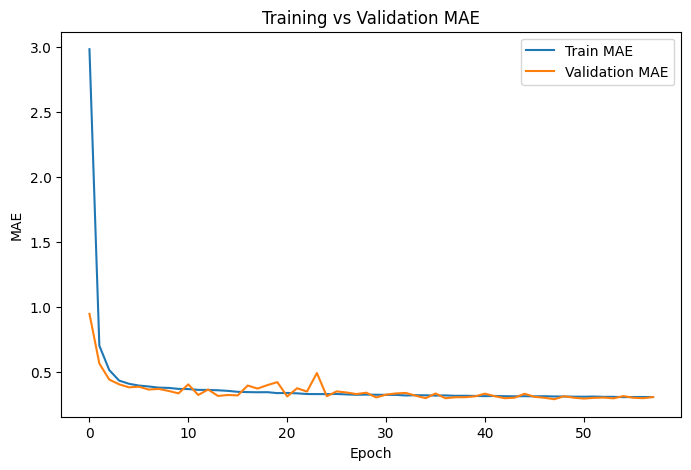

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Training vs Validation MAE')
plt.show()


The training and validation MAE decreased steadily throughout training and remained closely aligned, indicating continuous learning with minimal overfitting. The model converged to a low MAE of approximately **0.3 minutes**, reflecting strong predictive accuracy.


## Evaluating the Model on the Test Set

In [ ]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test MAE :", test_mae)

Test Loss: 0.1310179978609085
Test MAE : 0.29211583733558655


The model achieved a Test **MAE of 0.29 minutes**, indicating that, on average, the predicted delivery duration differs from the actual delivery duration by less than one minute. This suggests that the model is able to generate highly accurate predictions on unseen test data.


In [ ]:
# Predictions
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()
y_pred

550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


array([41.336903, 32.412815, 34.14333 , ..., 44.429485, 39.172832,
       64.93907 ], dtype=float32)

## Regression Metrics

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

baseline_mse = mean_squared_error(y_test, y_pred)
baseline_rmse = baseline_mse ** 0.5
baseline_mae = mean_absolute_error(y_test, y_pred)
baseline_r2 = r2_score(y_test, y_pred)

print("MSE :", baseline_mse)
print("RMSE:", baseline_rmse)
print("MAE :", baseline_mae)
print("R2  :", baseline_r2)

MSE : 0.1310179473938315
RMSE: 0.36196401394866795
MAE : 0.29211582477242753
R2  : 0.9985097172652859


## Actual vs Predicted Plot

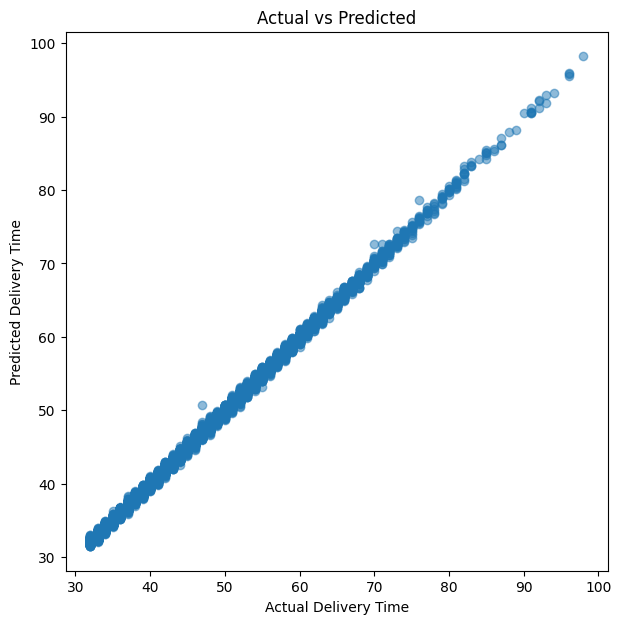

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted")
plt.show()

The scatter plot shows a strong agreement between the actual and predicted delivery durations. Most observations lie close to the reference line, with only a few points showing minor deviations, indicating high predictive accuracy and good model fit.


## Residual Analysis

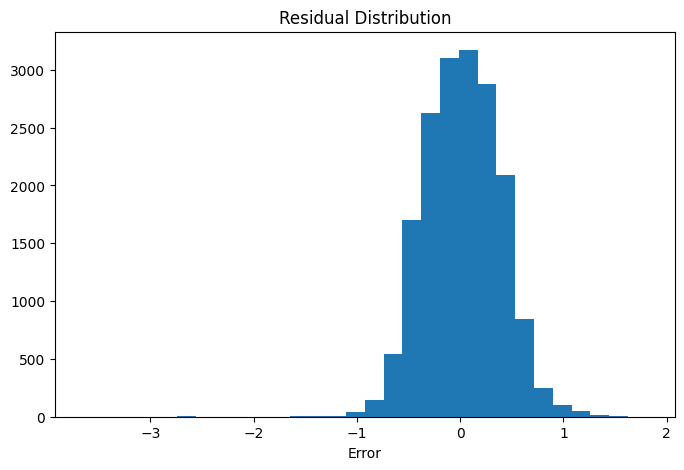

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

The residuals are centered around zero, indicating that the model does not consistently over-predict or under-predict delivery duration.

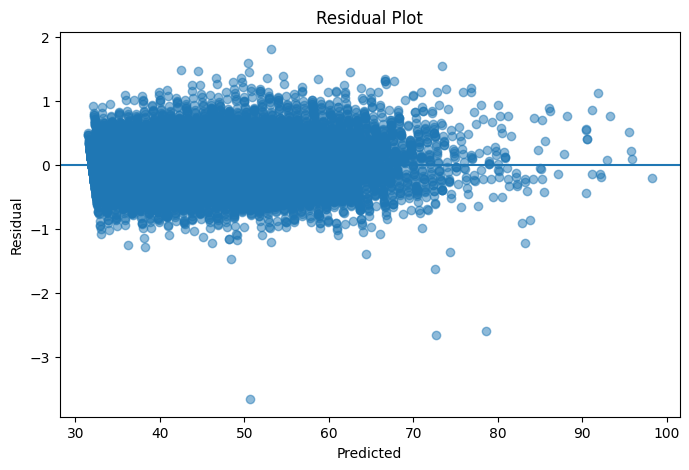

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

The residual plot confirms that the model's predictions are unbiased, with residuals centered around zero and no obvious patterns, indicating a good overall fit.

## ANN with Batch Normalization

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation

bn_model = Sequential([
    Dense(64),
    BatchNormalization(),
    Activation('relu'),

    Dense(32),
    BatchNormalization(),
    Activation('relu'),

    Dense(16),
    BatchNormalization(),
    Activation('relu'),

    Dense(1)
])

# Compile the model
bn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 10 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

bn_history = bn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 420.1205 - mae: 12.5265 - val_loss: 1.5841 - val_mae: 0.9393
Epoch 2/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 4.9575 - mae: 1.7104 - val_loss: 1.1299 - val_mae: 0.8102
Epoch 3/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 4.2793 - mae: 1.5955 - val_loss: 0.7836 - val_mae: 0.6836
Epoch 4/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 3.9022 - mae: 1.5232 - val_loss: 0.6053 - val_mae: 0.6095
Epoch 5/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - loss: 3.6392 - mae: 1.4748 - val_loss: 0.5863 - val_mae: 0.6011
Epoch 6/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 3.3611 - mae: 1.4206 - val_loss: 0.8390 - val_mae: 0.7306
Epoch 7/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 3.1714 - mae: 1.3816 - val_loss: 0.4995 - val_mae: 0.5460
Epoch 8/100
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - loss: 3.0296 - mae: 1.3539 - val_loss: 0.5296 - val_mae: 0.5715
Epoch 9/100
4395/4395

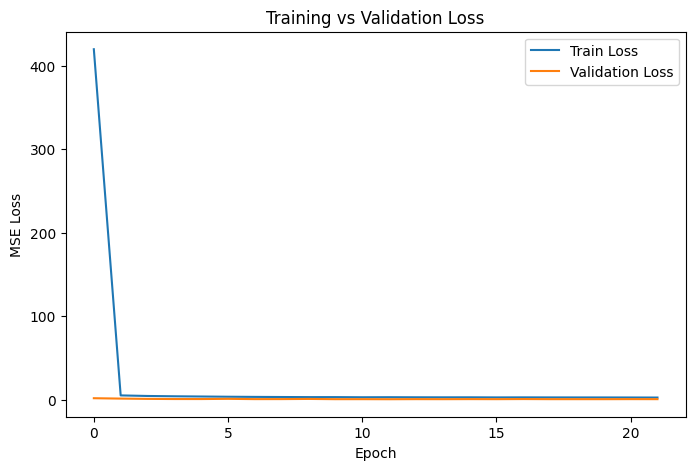

In [ ]:
# Plotting Learning curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
# Fixed variable names below
plt.plot(bn_history.history['loss'], label='Train Loss')
plt.plot(bn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


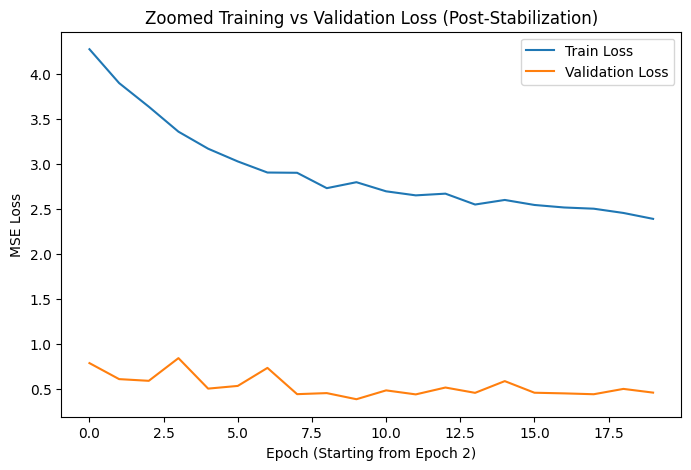

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# [2:] skips the extreme values of Epoch 0 and 1
plt.plot(bn_history.history['loss'][2:], label='Train Loss')
plt.plot(bn_history.history['val_loss'][2:], label='Validation Loss')

plt.xlabel('Epoch (Starting from Epoch 2)')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Zoomed Training vs Validation Loss (Post-Stabilization)')
plt.show()


Compared to the baseline ANN, the model with Batch Normalization achieved lower and more stable validation loss throughout training. The training loss gradually converged toward the validation loss, indicating improved generalization, more stable learning, and minimal overfitting.


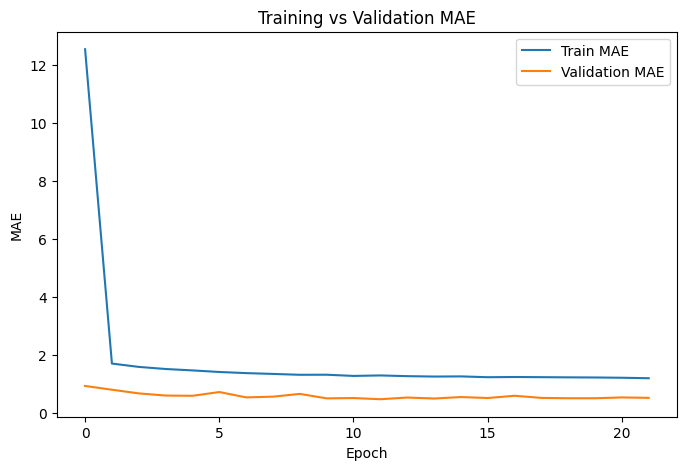

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(bn_history.history['mae'], label='Train MAE')
plt.plot(bn_history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Training vs Validation MAE')
plt.show()

The validation MAE consistently remained close to or lower than the training MAE, indicating strong generalization and minimal overfitting. This behavior suggests that Batch Normalization helped stabilize training and improve overall model performance.


In [ ]:
# Evaluation on Test Set
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test MAE :", test_mae)

Test Loss: 0.1310179978609085
Test MAE : 0.29211583733558655


The final ANN model achieved a test MAE of 0.29 minutes and a test MSE of 0.13. The close alignment between training, validation, and test performance indicates strong generalization and minimal overfitting.

In [ ]:
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()
y_pred

550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([41.336903, 32.412815, 34.14333 , ..., 44.429485, 39.172832,
       64.93907 ], dtype=float32)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

bn_mse = mean_squared_error(y_test, y_pred)
bn_rmse = bn_mse ** 0.5
bn_mae = mean_absolute_error(y_test, y_pred)
bn_r2 = r2_score(y_test, y_pred)

print("MSE :", bn_mse)
print("RMSE:", bn_rmse)
print("MAE :", bn_mae)
print("R2  :", bn_r2)

MSE : 0.1310179473938315
RMSE: 0.36196401394866795
MAE : 0.29211582477242753
R2  : 0.9985097172652859


## Training the Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_val)
print(f"Random Forest Validation MAE: {mean_absolute_error(y_val, rf_preds):.4f}")


Random Forest Validation MAE: 1.4474


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mse = mean_squared_error(y_val, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_val, rf_preds)
rf_r2 = r2_score(y_val, rf_preds)

print("Random MAE :", rf_mae)
print("Random MSE :", rf_mse)
print("Random RMSE:", rf_rmse)
print("Random R2  :", rf_r2)

Random MAE : 1.4474371373307544
Random MSE : 3.958191267493458
Random RMSE: 1.989520361165841
Random R2  : 0.9545762056004005


## Model Comparison

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],

    'Random Forest': [
        rf_mae,
        rf_mse,
        rf_rmse,
        rf_r2
    ],

    'Baseline ANN': [
        baseline_mae,
        baseline_mse,
        baseline_rmse,
        baseline_r2
    ],

    'ANN + BatchNorm': [
        bn_mae,
        bn_mse,
        bn_rmse,
        bn_r2
    ]
})

comparison

,Metric,Random Forest,Baseline ANN,ANN + BatchNorm
0,MAE,1.447437,0.292116,0.292116
1,MSE,3.958191,0.131018,0.131018
2,RMSE,1.989520,0.361964,0.361964
3,R2,0.954576,0.998510,0.998510


The ANN models outperformed the Random Forest model by achieving lower **MAE (0.29), MSE (0.13), and RMSE (0.36)**, along with a higher R² (0.9985)., suggesting that neural networks were more effective at learning the complex non-linear relationships between operational, temporal, and order-related features that influence delivery duration.


#**Recommendations**

**Improve Data Quality**

*  Investigate and correct negative values and other invalid records before providing the data to the analytics or data science team to ensure reliable analysis and accurate model predictions.

**Improve Operations During High-Delay Periods**
*  Since delivery times are highest during the early morning hours and on Mondays and Saturdays, adjust driver scheduling and restaurant staffing during these periods.

**Optimize Driver Allocation**
*  Monitor driver availability and proactively increase the number of active delivery partners during peak demand periods to reduce delivery delays.

**Balance Driver Workload**
*  When the number of busy drivers or outstanding orders is high, dynamically redistribute orders or incentivize additional drivers to come online.

**Optimize Route Planning**
*  Combine estimated driving duration with **real-time traffic data** to assign the nearest available delivery partner and recommend efficient routes. Future models can also incorporate **weather information** to improve route planning and ETA accuracy during adverse weather conditions.

**ANN Model for ETA Predictio**
*  Deploy the ANN model with Batch Normalization to generate real-time delivery time estimates, as it achieved the best predictive performance (R² ≈ 0.9985 and the lowest prediction error).

**Continuously Retrain the Model**

*  Periodically retrain the delivery prediction model with new order data to maintain prediction accuracy as customer demand and operational conditions evolve.

## 1. Defining the problem statements and where can this and modifications of this be used?

**Problem Statement**

Develop an Artificial Neural Network (ANN) regression model to accurately predict food delivery time based on order, restaurant, customer, and delivery partner information. The goal is to provide reliable ETAs and improve logistics efficiency.

**Where Can This Be Used?**

*  Provide accurate delivery estimates to customers.
*  Optimize delivery operations and route planning.
*  Improve customer satisfaction and operational efficiency.

**Possible Modifications**

*  Include real-time traffic and weather data.
*  Apply the model to grocery, courier, or e-commerce deliveries.
*  Predict delivery delays and recommend optimal delivery partners.

## 2. List 3 functions the pandas datetime provides with one line explanation

**1. dt.hour:**  Extracts the hour from a datetime column.

**2. dt.minute:** Extracts the minute from a datetime column.

**3. dt.dayofweek:**  Returns the day of the week as an integer (Monday = 0, Sunday = 6).

## 3. Short note on datetime, timedelta, time span (period)

**Datetime:** Represents a specific point in time (e.g., 2024-06-25 14:30:00). It is used to handle timestamps such as order creation or delivery time.

**Timedelta:** Represents the difference between two datetime values. It is used to calculate durations such as delivery time or time taken between events.

**Time Span / Period:** Represents a fixed duration or interval (e.g., hourly, daily, weekly). It is useful for grouping or analyzing data over specific time windows, such as average delivery time per hour or per day.

## 4. Why do we need to check for outliers in our data?

Outliers are checked to understand extreme values that may distort model learning or indicate data issues. Identifying them helps decide whether to retain, transform, or remove them based on whether they represent valid real-world behavior or noise.


## 5. Name 3 outlier removal methods?

1. IQR Method (Interquartile Range)

2. Z-Score Method

3. Percentile / Quantile Capping (Winsorization)

## 6. What classical machine learning methods can we use for this problem?

We can use:
1. Linear Models
   *  Ridge Regression
   *  Lasso Regression
   *  Elastic Net Regression
2. Tree-based models
  *  Decision Tree Regressor
  *  Random Forest Regressor
  *  Gradient Boosting Regressor
  *  XGBoost / LightGBM / CatBoost


## 7. Why is scaling required for neural networks?

Scaling is required in neural networks to ensure all features are on a similar range, which helps gradient-based optimizers converge faster and more stably. Without scaling, features with larger values can dominate the learning process, leading to unstable or slow convergence.


## 8. Briefly explain your choice of optimizer.

**Adam** was chosen because it **automatically** adjusts the **learning rate** during training, making the learning process faster and more stable. It combines the benefits of **momentum and RMSprop**, which helps the model converge efficiently with **minimal manual tuning**. It is especially effective for large datasets.


# 9. Which activation function did you use and why?

ReLU (Rectified Linear Unit) was used in the hidden layers because it introduces non-linearity, enables faster training, and helps reduce the vanishing gradient problem. A linear activation function was used in the output layer since the model predicts a continuous delivery time.

## 10. Why does a neural network perform well on a large dataset?

Neural networks perform well on large datasets because they can learn complex patterns and relationships from large amounts of data. More training data helps the model generalize better and reduces the risk of overfitting.